In [43]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from skimage import util, filters, color
from skimage.segmentation import watershed
from skimage.measure import label
from skimage.restoration import inpaint_biharmonic
from skimage.feature import match_template, peak_local_max

from scipy.stats import norm

from matplotlib import cm

from stm_voronoi_mst import img_file, gray_process, voronoi_tree, find_nodes, graph_from_peaks, statistics

In [44]:
# FILE NAME
f = r"copy_scale_5.png"

# GRAYSCALE PROCESS
dsize = 11
cutoff = 0.3

# WATERSHED
smooth = False
sigma = 10
low_th = 0.2
high_th = 0.8

# VORONOI
k = 24
power = 0.3

C:\Users\Matth\AppData\Local\Temp\ipykernel_5688\2917538942.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('afmhot')


Text(0.5, 1.0, 'Inverted Gray Scale Image')

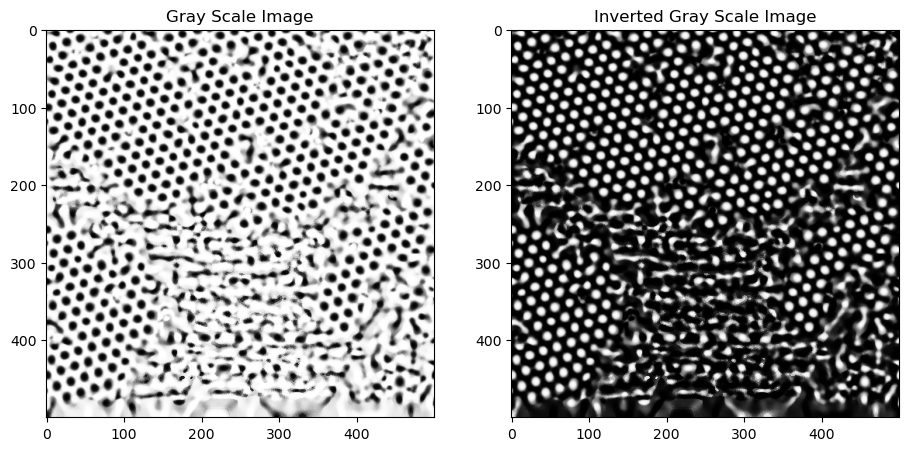

In [45]:
img = img_file(f)
img.load()

img2d = img.img if img.img.ndim == 2 else img.img.mean(axis = 2)
row_means = img2d.mean(axis = 1)
row_devs = np.abs(img2d - row_means[:, None])

max_dev_per_row = row_devs.max(axis = 1)
threshold = max_dev_per_row.mean() + 0.9 * max_dev_per_row.std()
scarred_rows = max_dev_per_row > threshold

mask = np.zeros(img2d.shape, dtype = bool)
mask[scarred_rows, :] = True

if img.img.ndim == 2:
    inpainted = inpaint_biharmonic(img.img, mask)
else:
    inpainted = np.stack([inpaint_biharmonic(img.img[..., c], mask) for c in range(img.img.shape[2])], axis = -1)

img.img_inpainted = inpainted
img.scar_mask = mask

source = (img.img_inpainted if hasattr(img, 'img_inpainted') else img.img)
img.img_blurred = filters.gaussian(source, sigma = 3, channel_axis = -1 if source.ndim == 3 else None)

if img.img_blurred.ndim == 3:
    image_gray = np.dot(img.img_blurred[..., :3], [0.2989, 0.5898, 0.1140])
else:
    image_gray = img.img_blurred

image_norm = (image_gray - image_gray.min()) / (image_gray.max() - image_gray.min())

cmap = cm.get_cmap('afmhot')
colored_image = cmap(image_norm)

img_gr = gray_process(colored_image, dsize = dsize, cutoff = cutoff)

fig, ax = plt.subplots(1, 2, figsize = (11, 6))
im0 = ax[0].imshow(img_gr, cmap = 'gray')
ax[0].set_title('Gray Scale Image')
im1 = ax[1].imshow(util.invert(img_gr), cmap = 'gray')
ax[1].set_title('Inverted Gray Scale Image')


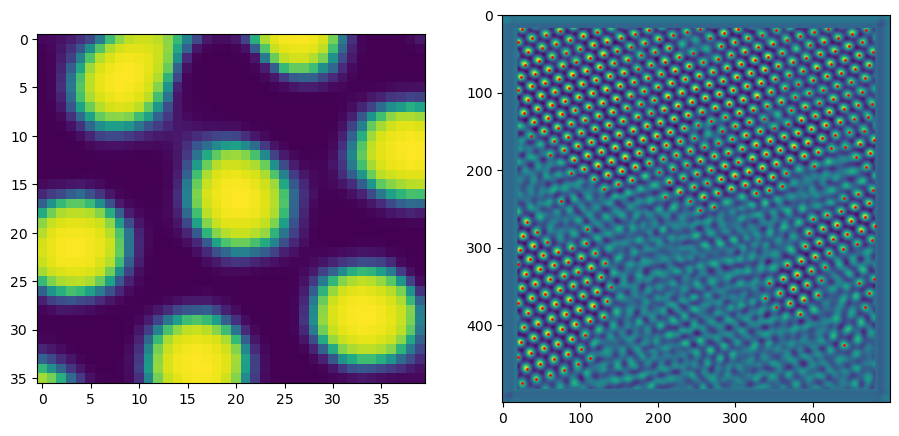

In [46]:
image = 255 - img_gr
pore = image[59:95, 70:110]

result = match_template(image, pore, pad_input = True)
peaks = peak_local_max(result, min_distance = 10, threshold_rel = 0.5)

fig, ax = plt.subplots(1, 2, figsize = (11, 6))
im0 = ax[0].imshow(pore)
im1 = ax[1].imshow(result)
plt.plot(peaks[:, 1], peaks[:, 0], 'o', markeredgecolor = 'r', markersize = '1')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [177.80063773583606..178.76680188877572].


Text(0.5, 1.0, 'Segments Overlayed on Data')

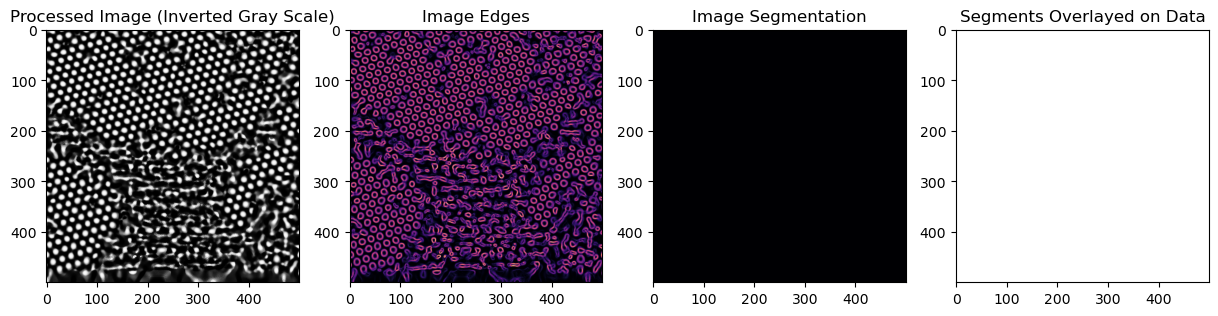

In [47]:
if smooth == 3:
    smoothed = filters.gaussian(image, sigma)
    edges = filters.sobel(smoothed)
else:
    edges = filters.sobel(img_gr)

markers = np.zeros_like(image, dtype = np.int32)
markers [image < low_th] = 2
markers [image > high_th] = 1

segmentation = watershed(edges, markers)
label_mask, Nlabel = label(segmentation, background = 2, return_num = True)
img_label_overlay = color.label2rgb(label_mask, image = image)

fig, ax = plt.subplots(1, 4, figsize = (15, 10))
im0 = ax[0].imshow(image, cmap = 'gray')
ax[0].set_title('Processed Image (Inverted Gray Scale)')

im1 = ax[1].imshow(edges, cmap = 'magma')
ax[1].set_title('Image Edges')

im2 = ax[2].imshow(segmentation, cmap = 'magma')
ax[2].set_title('Image Segmentation')

im3 = ax[3].imshow(img_label_overlay)
ax[3].set_title('Segments Overlayed on Data')

In [48]:
# Build graph nodes directly from detected peak coordinates
def graph_from_peaks(peaks, scale=1, min_dist=None, area=None):
    """
    Convert peak coordinates into graph nodes.

    Parameters
    ----------
    peaks : array-like
        Array of peak coordinates as (row, col) pairs.
    scale : float
        Pixel-to-nm conversion ratio.
    min_dist : float, optional
        Minimum allowed pixel distance between output nodes.
    area : float, optional
        Physical area assigned to every node (nm^2). If None, defaults to 1 pixel^2.

    Returns
    -------
    G : networkx.Graph
        Graph with nodes at peak locations.
    """
    peaks = np.asarray(peaks, dtype=np.float32)
    if peaks.ndim != 2 or peaks.shape[1] != 2:
        raise ValueError('peaks must be an array of shape (N, 2)')

    if area is None:
        area = 1.0 / scale**2

    if min_dist is not None:
        keep = []
        for peak in peaks:
            if all(np.linalg.norm(peak - kept) >= min_dist for kept in keep):
                keep.append(peak)
        peaks = np.asarray(keep, dtype=np.float32)

    G = nx.Graph()
    for idx, pos in enumerate(peaks, start=1):
        G.add_node(idx, pixel_pos=pos, area=area)

    n = G.number_of_nodes
    return G, n


In [49]:
graph_node, n = graph_from_peaks(peaks, scale = img.scale, min_dist = 10, area = 1 / img.scale ** 2)

img_vor_t, img_vor_deg_t, v_border, graph_node, graph_inner, p, k_1 = voronoi_tree(img, graph_node, k = k, power = power)

g_msf = nx.minimum_spanning_tree(graph_inner, weight = 'dis')

Text(0.5, 1.0, 'Voronoi Overlay (Original)')

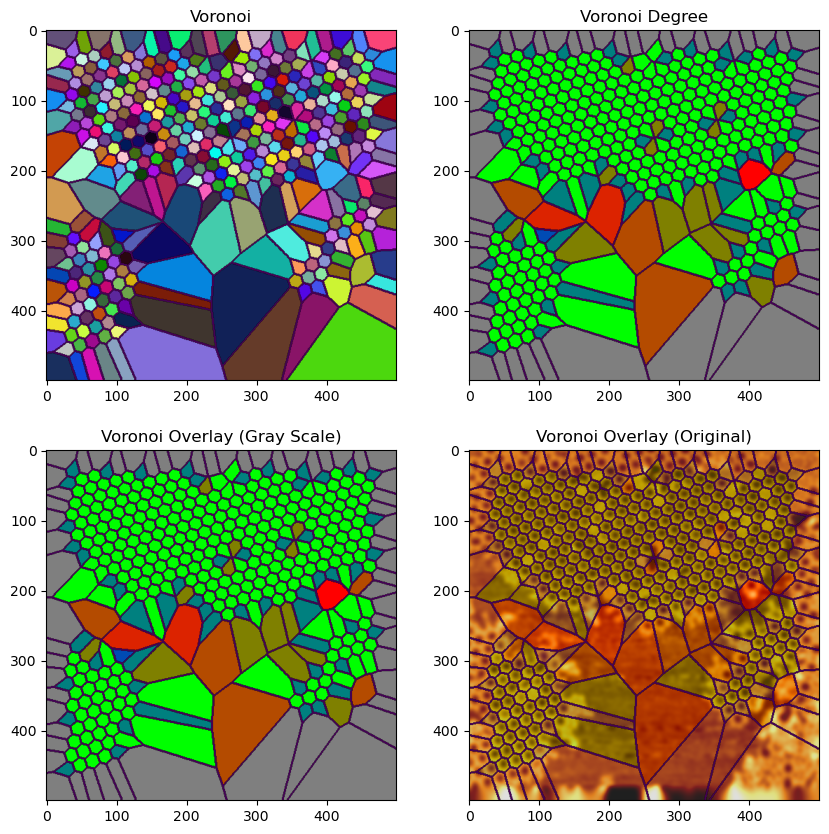

In [50]:
fig, ax = plt.subplots(2, 2, figsize = (10, 10))
ax[0, 0].imshow(img_vor_t)
ax[0, 0].imshow(v_border)
ax[0, 0].set_title('Voronoi')

ax[0, 1].imshow(img_vor_deg_t)
ax[0, 1].imshow(v_border)
ax[0, 1].set_title('Voronoi Degree')

ax[1, 0].imshow(img_gr, cmap = 'gray')
ax[1, 0].imshow(img_vor_deg_t)
ax[1, 0].imshow(v_border)
ax[1, 0].set_title('Voronoi Overlay (Gray Scale)')

ax[1, 1].imshow(colored_image)
ax[1, 1].imshow(img_vor_deg_t, alpha = 0.25)
ax[1, 1].imshow(v_border)
ax[1, 1].set_title('Voronoi Overlay (Original)')

<function matplotlib.pyplot.show(close=None, block=None)>

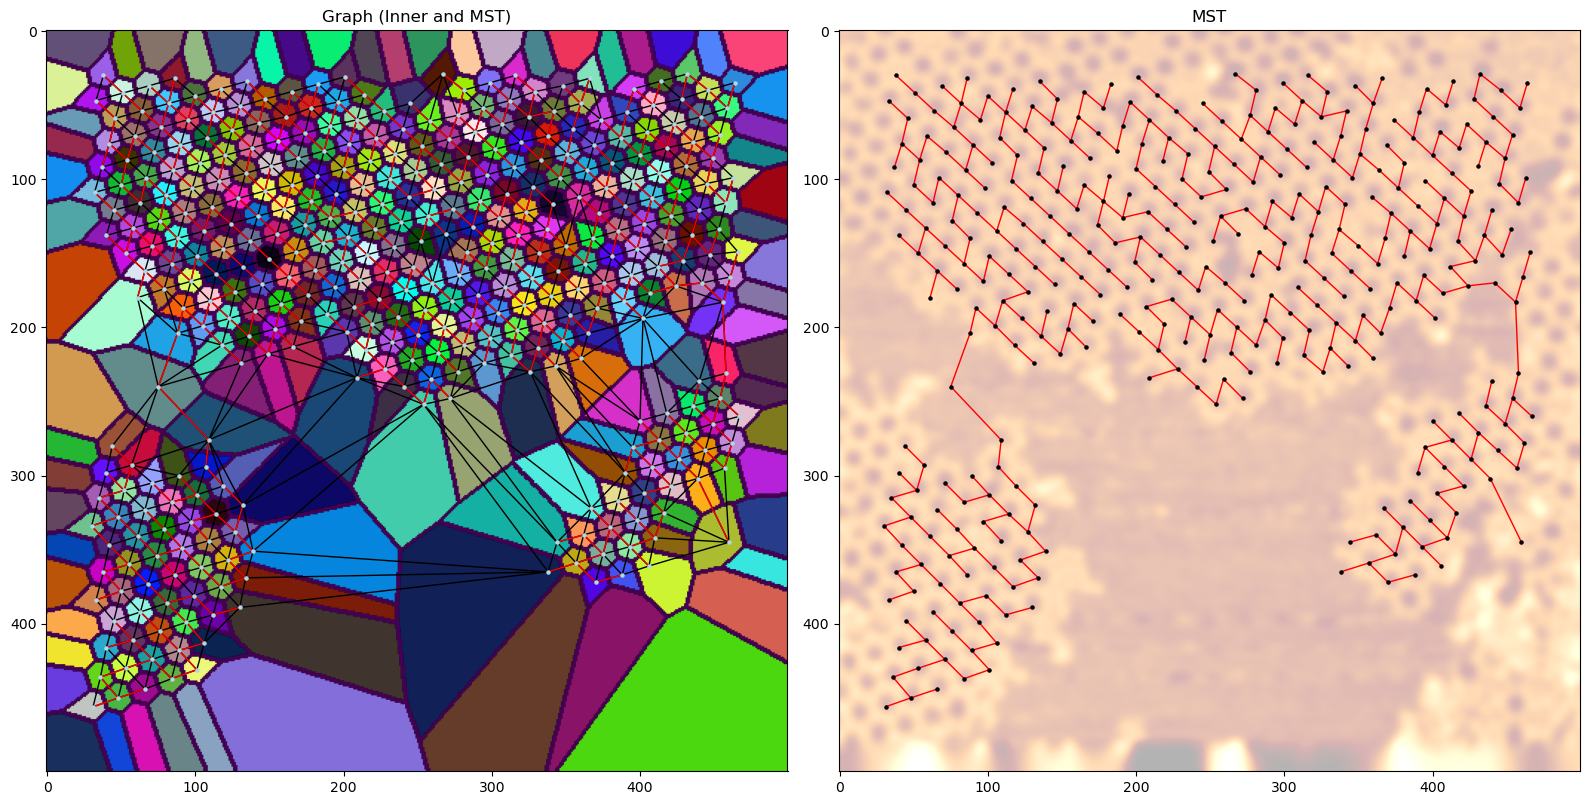

In [56]:
pos = {n:d['pixel_pos'] for n, d in graph_inner.nodes(data = True)}
pos_inner = {
            node: [dat['pixel_pos'][1], dat['pixel_pos'][0]]
            for node, dat in graph_inner.nodes(data = True)
            }
pos_msf = {
            node: [dat['pixel_pos'][1], dat['pixel_pos'][0]]
            for node, dat in g_msf.nodes(data = True)
            }

fig, ax = plt.subplots(1, 2 ,figsize = (16, 20))

ax[0].imshow(img_vor_t)
ax[0].imshow(v_border)
ax[0].set_title('Graph (Inner and MST)')

xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()

nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'lightblue', node_size = 5, 
                      ax = ax[0], hide_ticks = False)
nx.draw_networkx_edges(graph_inner, pos_inner, edge_color = 'black', 
                       ax = ax[0], hide_ticks = False)

nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', 
                       ax = ax[0], hide_ticks = False)

ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)

ax[1].imshow(colored_image, alpha = 0.3)
ax[1].set_title('MST')
nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'black', node_size = 5, 
                       ax = ax[1], hide_ticks = False)
nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', 
                       ax = ax[1], hide_ticks = False)

ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)

plt.tight_layout()
plt.show
